In [1]:
import numpy as np
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt
import math
import os

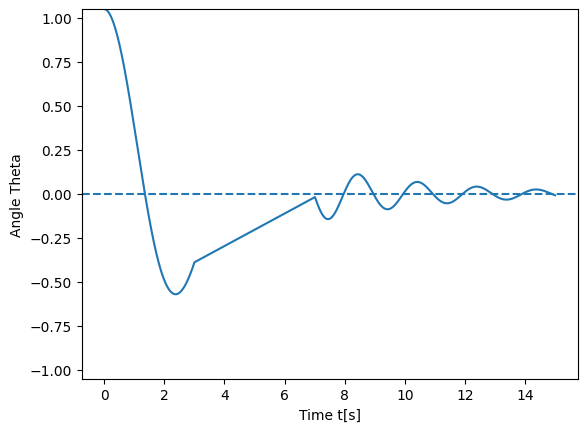

In [ ]:
df = pd.read_csv('train/pendulum_train.csv')
plt.plot(df['t'], df['theta'])
plt.xlabel('Time t[s]')
plt.ylabel('Angle Theta')
max_y = abs(df['theta']).max()
plt.ylim(-max_y, max_y)
plt.axhline(0, linestyle='--')

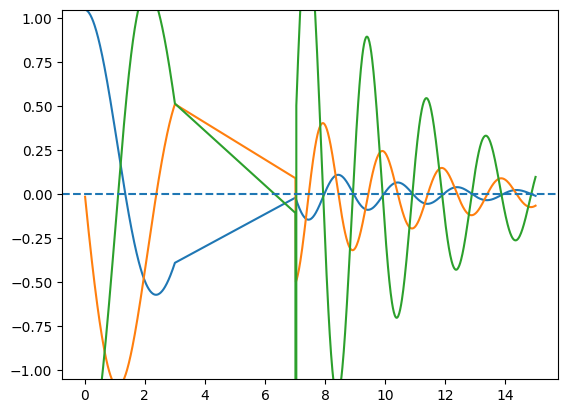

In [59]:
def find_derrivative(data, name, param1, param2):
    data[name] = data[param1].diff()/data[param2].diff()

find_derrivative(df, 'w', 'theta', 't')
find_derrivative(df, 'alpha', 'w', 't')

plt.plot(df['t'], df['theta'])
plt.plot(df['t'], df['w'])
plt.plot(df['t'], df['alpha'])
max_y = abs(df['theta']).max()
plt.ylim(-max_y, max_y)
plt.axhline(0, linestyle='--')

In [126]:
df = df.dropna()

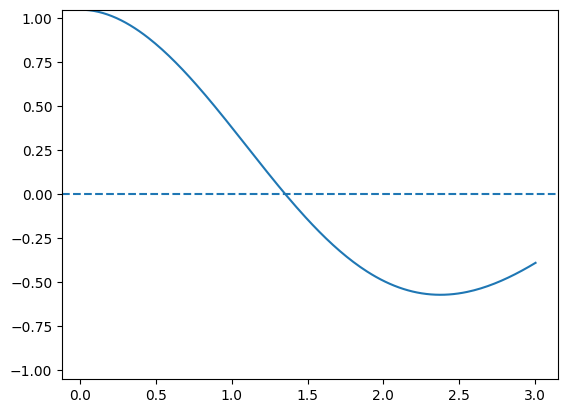

In [127]:
cut_off_point = df['t'].diff().argmax()
df_before = df.iloc[:cut_off_point]
plt.plot(df_before['t'], df_before['theta'])
plt.ylim(-max_y, max_y)
plt.axhline(0, linestyle='--')

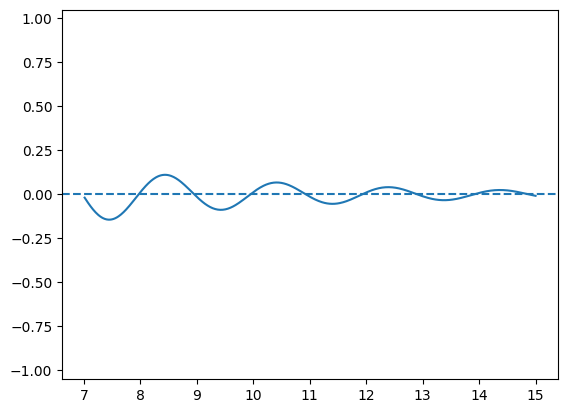

In [128]:
df_after = df.iloc[cut_off_point:]
plt.plot(df_after['t'], df_after['theta'])
plt.ylim(-max_y, max_y)
plt.axhline(0, linestyle='--')

In [129]:
df_before = df_before.dropna()
df_after = df_after.dropna()
df_before.head()

,t,theta,w,alpha
2,0.030030,1.049222,-0.038843,-1.721738
3,0.045045,1.048253,-0.064491,-1.708136
4,0.060060,1.046903,-0.089933,-1.694460
5,0.075075,1.045174,-0.115165,-1.680445
6,0.090090,1.043069,-0.140182,-1.666150


In [130]:
df_after['alpha']

201    -0.105038
202   -39.262805
203     0.505867
204     0.576463
205     0.645210
         ...    
729     0.061224
730     0.071208
731     0.080962
732     0.090450
733     0.099663
Name: alpha, Length: 533, dtype: float64

In [131]:
df_after = df_after[2:]

In [132]:
def train(model,theta,w,alpha,epochs,lr, is_after):
    theta = torch.tensor(theta.to_numpy())
    w = torch.tensor(w.to_numpy())
    alpha = torch.tensor(alpha.to_numpy())

    optimizer = torch.optim.Adam(model.parameters(), lr, weight_decay=0)
    criterion = nn.MSELoss()
    
    for i in range (epochs): 
        model.train()
        preds = model(theta, w, is_after).squeeze()
        # print(preds)
        # print(alpha)
        loss = criterion(preds, alpha)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 5000 == 0:
            print(f'Epoch [{i+1}], Loss: {loss.item():.25f}')
        
        if loss.item()<0.00000000001:
            print(f"Stop at epoch: {i+1}, loss: {loss.item()}")
            break

In [ ]:
class SimplePendulum(nn.Module):
    def __init__(self):
        super(SimplePendulum, self).__init__()
        self.alpha = nn.Parameter(torch.randn((1), requires_grad=True))
        self.beta1 = nn.Parameter(torch.randn((1), requires_grad=True))
        self.beta2 = nn.Parameter(torch.randn((1), requires_grad=True))

    def forward(self, theta, w, is_after):
        if is_after:
            return -self.alpha*w - self.beta1*torch.sin(theta)
        else:
            return  -self.alpha*w - self.beta2*torch.sin(theta)
    
model = SimplePendulum()

train(model, df_before['theta'], df_before['w'], df_before['alpha'], int(2e4), 1e-3, is_after=False)
train(model, df_after['theta'], df_after['w'], df_after['alpha'], int(2e4), 1e-3, is_after=True)

Epoch [5000], Loss: 0.0000035583952695262071330
Epoch [10000], Loss: 0.0000035583923796304992279
Epoch [15000], Loss: 0.0000035583924131626891954
Epoch [20000], Loss: 0.0000035583924696221861377
Epoch [5000], Loss: 0.1497366362570307085633203
Epoch [10000], Loss: 0.0232483091273449835045817
Epoch [15000], Loss: 0.0000269798898153722369140
Epoch [20000], Loss: 0.0000000033496269058079014
Epoch [5000], Loss: 0.0025871297321109053973798
Epoch [10000], Loss: 0.0005598424850896935225236


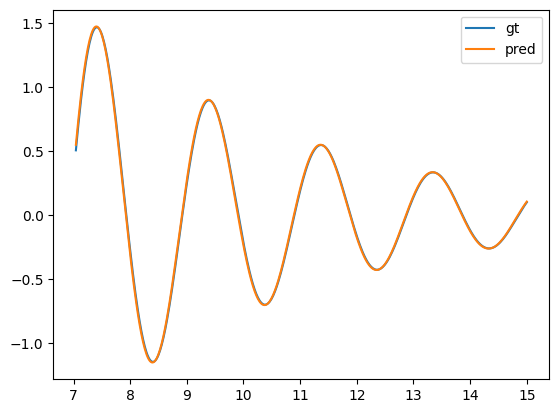

In [216]:
def eval(model, df, is_after):
    model.eval()
    theta = torch.tensor(df['theta'].to_numpy())
    w = torch.tensor(df['w'].to_numpy())
    with torch.no_grad():
        preds = model(theta, w, is_after)
    return preds

preds_after = eval(model, df_after, is_after=True)
plt.plot(df_after['t'], df_after['alpha'], label='gt')
plt.plot(df_after['t'], preds_after, label='pred')
plt.legend()
# plt.ylim(-max_y, max_y)
# plt.axhline(0, linestyle='--')

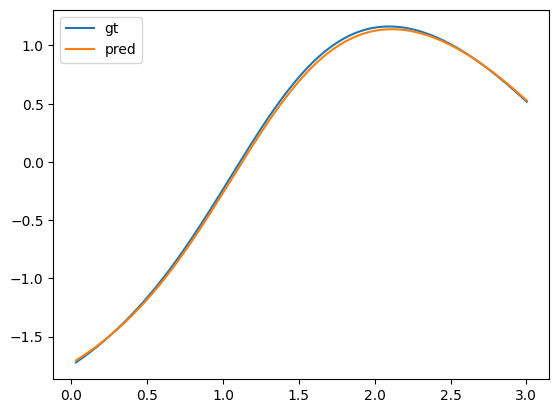

In [217]:
preds_before = eval(model, df_before, is_after=False)
plt.plot(df_before['t'], df_before['alpha'], label='gt')
plt.plot(df_before['t'], preds_before, label='pred')
plt.legend()

In [218]:
step = df['t'].diff().dropna().mode()[0]
t_full = np.arange(df['t'].min(), df['t'].max() + step, step)

C:\Users\raian\AppData\Local\Temp\ipykernel_23472\1835221370.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  step = torch.tensor(step)


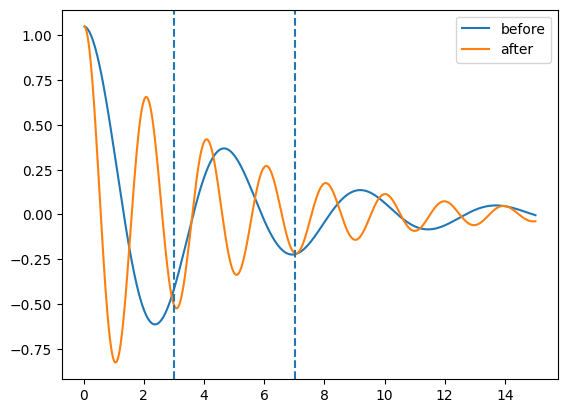

In [227]:
model.eval()
with torch.no_grad():
    step = torch.tensor(step)
    last_theta, last_w = torch.tensor(df.head(1)['theta'].to_numpy()), torch.tensor(df.head(1)['w'].to_numpy())
    preds_theta_before = []
    for t in t_full:
        preds_theta_before.append(last_theta.item())
        alpha = model(last_theta, last_w, False)
        last_w += alpha*step
        last_theta += last_w * step

    last_theta, last_w = torch.tensor(df.head(1)['theta'].to_numpy()), torch.tensor(df.head(1)['w'].to_numpy())
    preds_theta_after = []
    for t in t_full:
        preds_theta_after.append(last_theta.item())
        alpha = model(last_theta, last_w, True)
        last_w += alpha*step
        last_theta += last_w * step

plt.plot(t_full, preds_theta_before, label='before')
plt.plot(t_full, preds_theta_after, label = 'after')
plt.axvline(df['t'][cut_off_point+1], linestyle='--')
plt.axvline(df['t'][cut_off_point+2], linestyle='--')
plt.legend()

In [193]:
df['t'][cut_off_point+2]

np.float64(7.012012012012012)

In [202]:
t_full[465]

np.float64(7.012012011981979)

In [210]:
np.where(abs(t_full - df['t'][cut_off_point+1])<step)[0]

array([198, 199])

In [211]:
np.where(abs(t_full - df['t'][cut_off_point+2])<step)[0]


array([465, 466])

In [ ]:
from tqdm import tqdm
has_data_t = df['t'][cut_off_point+2]
best_loss = np.inf
best_tf = 0
start_idx = t_full

model.eval()
with torch.no_grad():
    for tf in tqdm(t_full[198:466]):
        loss = 0
        is_after = False
        last_theta, last_w = torch.tensor(df.head(1)['theta'].to_numpy()), torch.tensor(df.head(1)['w'].to_numpy())
        preds_theta_before = []
        i = 0
        for t in t_full:
            if t == tf:
                is_after=True
            preds_theta_before.append(last_theta.item())
            alpha = model(last_theta, last_w, is_after)
            last_w += alpha*step
            last_theta += last_w * step
            if t >= has_data_t:
                loss+=(last_theta.item()-df['t'][cut_off_point+2+i])**2
                i+=1

        if loss < best_loss:
            best_loss=loss
            best_tf=tf

best_tf

100%|██████████| 268/268 [00:09<00:00, 27.40it/s]


np.float64(6.456456456426424)

C:\Users\raian\AppData\Local\Temp\ipykernel_23472\631996862.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  step = torch.tensor(step)


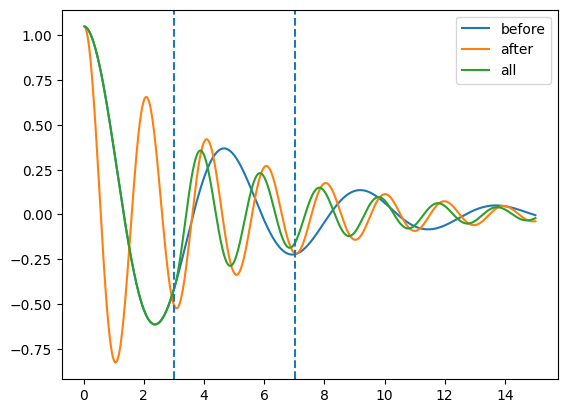

In [237]:
model.eval()
with torch.no_grad():
    step = torch.tensor(step)
    last_theta, last_w = torch.tensor(df.head(1)['theta'].to_numpy()), torch.tensor(df.head(1)['w'].to_numpy())
    preds_theta_all = []
    is_after = False
    for t in t_full:
        if(t==t_full[200]):
            is_after = True
        preds_theta_all.append(last_theta.item())
        alpha = model(last_theta, last_w, is_after)
        last_w += alpha*step
        last_theta += last_w * step

plt.plot(t_full, preds_theta_before, label='before')
plt.plot(t_full, preds_theta_after, label = 'after')
plt.plot(t_full, preds_theta_all, label = 'all')
plt.axvline(df['t'][cut_off_point+1], linestyle='--')
plt.axvline(df['t'][cut_off_point+2], linestyle='--')
plt.legend()

In [ ]:
g = 9.81
l = g/model.beta1
F = model.beta2*l - g
nu = model.alpha